✅ arch installed
Added to path: /workspaces/myfolder/sas-curiosity-cup-2025
✅ All imports successful!
✅ Imports successful


/workspaces/myfolder/sas-curiosity-cup-2025/src/data/fetch.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False)


Downloaded 500 days of data
Downloaded 500 days of data
✅ Downloaded 499 days
Current price: $187.67
Historical mu: 69.76%
Historical sigma: 51.01%

Fitting GARCH(1,1) model...

GARCH Volatility Forecast (180 days):
  Average: 47.02%
  Min: 36.99%
  Max: 49.44%
  Historical vol: 51.01%

Running Monte Carlo with GARCH volatility...
Simulation 0/5000


/workspaces/myfolder/sas-curiosity-cup-2025/src/data/fetch.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False)
/workspaces/myfolder/sas-curiosity-cup-2025/src/data/fetch.py:83: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(data['Close'].iloc[-1])
/workspaces/myfolder/sas-curiosity-cup-2025/src/data/fetch.py:58: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  mu = float(daily_mean * 252)
/workspaces/myfolder/sas-curiosity-cup-2025/src/data/fetch.py:59: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  sigma = float(daily_std * np.sqrt(252))


Simulation 1000/5000
Simulation 2000/5000
Simulation 3000/5000
Simulation 4000/5000

Results (6-month forecast with GARCH):
  Expected price: $282.98
  Median price: $260.72
  95% VaR: $127.63
  Prob of loss: 23.3%
  Prob of 20%+ loss: 10.1%


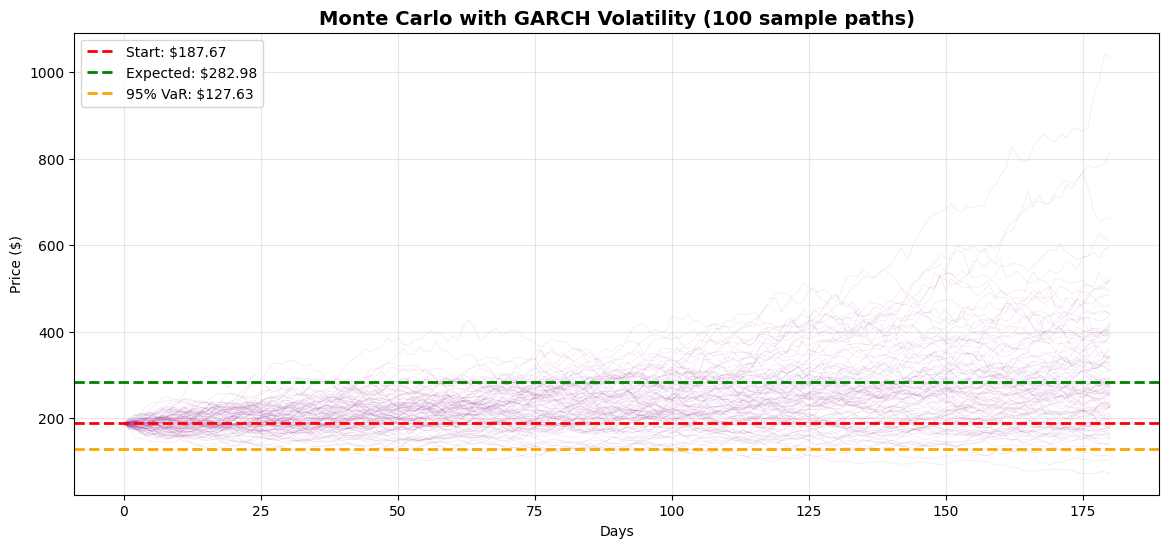


✅ Integration test complete!


In [3]:
# Cell 1: Setup
import sys
import os
import sys
import subprocess
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

subprocess.run([sys.executable, "-m", "pip", "install", "arch", "-q"])
print("✅ arch installed")
# Get the repo root directory
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(repo_root)

print(f"Added to path: {repo_root}")

from src.models.garch import GARCHVolatilityForecaster
from src.models.monte_carlo_advanced import JumpDiffusionMC
from src.data.fetch import download_stock_data, calculate_returns, get_stock_parameters

print("✅ All imports successful!")
print("✅ Imports successful")

# Cell 2: Download NVDA data (2 years)
end = datetime.now().strftime('%Y-%m-%d')
start = (datetime.now() - timedelta(days=730)).strftime('%Y-%m-%d')

print(f"Downloading NVDA from {start} to {end}...")
data = download_stock_data('NVDA', start, end)
returns = calculate_returns(data)
params = get_stock_parameters('NVDA', start, end)

print(f"✅ Downloaded {len(returns)} days")
print(f"Current price: ${params['S0']:.2f}")
print(f"Historical mu: {params['mu']*100:.2f}%")
print(f"Historical sigma: {params['sigma']*100:.2f}%")

# Cell 3: Fit GARCH and get volatility forecast
print("\nFitting GARCH(1,1) model...")
garch = GARCHVolatilityForecaster(returns)
garch.fit()

# Get 180-day forecast
garch_forecast = garch.forecast_volatility(horizon=180)

# Use average for Monte Carlo
avg_garch_vol = garch_forecast.mean()

print(f"\nGARCH Volatility Forecast (180 days):")
print(f"  Average: {avg_garch_vol*100:.2f}%")
print(f"  Min: {garch_forecast.min()*100:.2f}%")
print(f"  Max: {garch_forecast.max()*100:.2f}%")
print(f"  Historical vol: {params['sigma']*100:.2f}%")

# Cell 4: Run Monte Carlo WITH GARCH volatility
print("\nRunning Monte Carlo with GARCH volatility...")
mc_garch = JumpDiffusionMC(
    S0=params['S0'],
    mu=params['mu'],
    sigma=avg_garch_vol,  # USE GARCH FORECAST
    days=180
)

paths = mc_garch.run_simulation(n_simulations=5000)
final_prices = paths[:, -1]
stats = mc_garch.calculate_statistics(final_prices)

print(f"\nResults (6-month forecast with GARCH):")
print(f"  Expected price: ${stats['mean']:.2f}")
print(f"  Median price: ${stats['median']:.2f}")
print(f"  95% VaR: ${stats['var_95']:.2f}")
print(f"  Prob of loss: {stats['prob_loss']*100:.1f}%")
print(f"  Prob of 20%+ loss: {stats['prob_large_loss']*100:.1f}%")

# Cell 5: Visualize sample paths
plt.figure(figsize=(14, 6))
for i in range(100):
    plt.plot(paths[i], alpha=0.1, color='purple', linewidth=0.5)

plt.axhline(y=params['S0'], color='red', linestyle='--', linewidth=2, label=f"Start: ${params['S0']:.2f}")
plt.axhline(y=stats['mean'], color='green', linestyle='--', linewidth=2, label=f"Expected: ${stats['mean']:.2f}")
plt.axhline(y=stats['var_95'], color='orange', linestyle='--', linewidth=2, label=f"95% VaR: ${stats['var_95']:.2f}")

plt.title('Monte Carlo with GARCH Volatility (100 sample paths)', fontweight='bold', fontsize=14)
plt.xlabel('Days')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n✅ Integration test complete!")